# Discrete-Time Markov Chains

In probability theory and mathematical finance, a Markov Chain is a stochastic model describing a sequence of possible events in which the probability of each event depends only on the state attained in the previous event. This memoryless property makes Markov Chains incredibly powerful for modeling regime changes in financial markets, credit rating migrations, and interest rate term structures.

## 1. Theoretical Framework

### The Markov Property

Let $(\Omega, \mathcal{F}, \mathbb{P})$ be a probability space and let $S$ be a countable set called the **state space**. A discrete-time stochastic process $\{X_t\}_{t \in \mathbb{N}_0}$ taking values in $S$ is a **Markov Chain** if it satisfies the Markov property:

$$
\mathbb{P}(X_{t+1} = j \mid X_t = i, X_{t-1} = i_{t-1}, \dots, X_0 = i_0) = \mathbb{P}(X_{t+1} = j \mid X_t = i)
$$

for all $t \geq 0$ and all states $i_0, \dots, i_{t-1}, i, j \in S$. The future state depends strictly on the present state, rendering the past history conditionally irrelevant.

### The Transition Matrix

If the state space $S$ is finite, say $S = \{1, 2, \dots, K\}$, we define the **one-step transition probabilities** $p_{ij} = \mathbb{P}(X_{t+1} = j \mid X_t = i)$. Assuming the chain is time-homogeneous (the probabilities do not change with $t$), we can collect these into a $K \times K$ **transition matrix** $P$:

$$
P = \begin{bmatrix}
p_{11} & p_{12} & \dots & p_{1K} \\
p_{21} & p_{22} & \dots & p_{2K} \\
\vdots & \vdots & \ddots & \vdots \\
p_{K1} & p_{K2} & \dots & p_{KK}
\end{bmatrix}
$$

By definition, $P$ is a row-stochastic matrix:
1.  $p_{ij} \geq 0 \quad \forall i, j \in S$
2.  $\sum_{j=1}^K p_{ij} = 1 \quad \forall i \in S$

### The Chapman-Kolmogorov Equations

To find the probability of transitioning from state $i$ to state $j$ in $n$ steps, denoted $p_{ij}^{(n)} = \mathbb{P}(X_{t+n} = j \mid X_t = i)$, we rely on the Chapman-Kolmogorov equations. In matrix notation, the $n$-step transition matrix is simply the one-step transition matrix raised to the $n$-th power:

$$
P^{(n)} = P^n
$$

### Stationary Distribution

A fundamental question in the study of Markov Chains is the long-run behavior of the process. A probability vector $\boldsymbol{\pi} = [\pi_1, \pi_2, \dots, \pi_K]$ is a **stationary distribution** (or invariant measure) for the Markov Chain with transition matrix $P$ if:

$$
\boldsymbol{\pi} P = \boldsymbol{\pi} \quad \text{and} \quad \sum_{i=1}^K \pi_i = 1
$$

Mathematically, $\boldsymbol{\pi}$ is the normalized left eigenvector of $P$ associated with the eigenvalue $\lambda = 1$. For a finite, irreducible, and aperiodic Markov chain, this stationary distribution exists, is unique, and represents the equilibrium probability of the chain being in each state as $t \to \infty$.


Theoretical Stationary Distribution (π):
  Bull: 0.4015
  Bear: 0.2920
  Stagnant: 0.3066


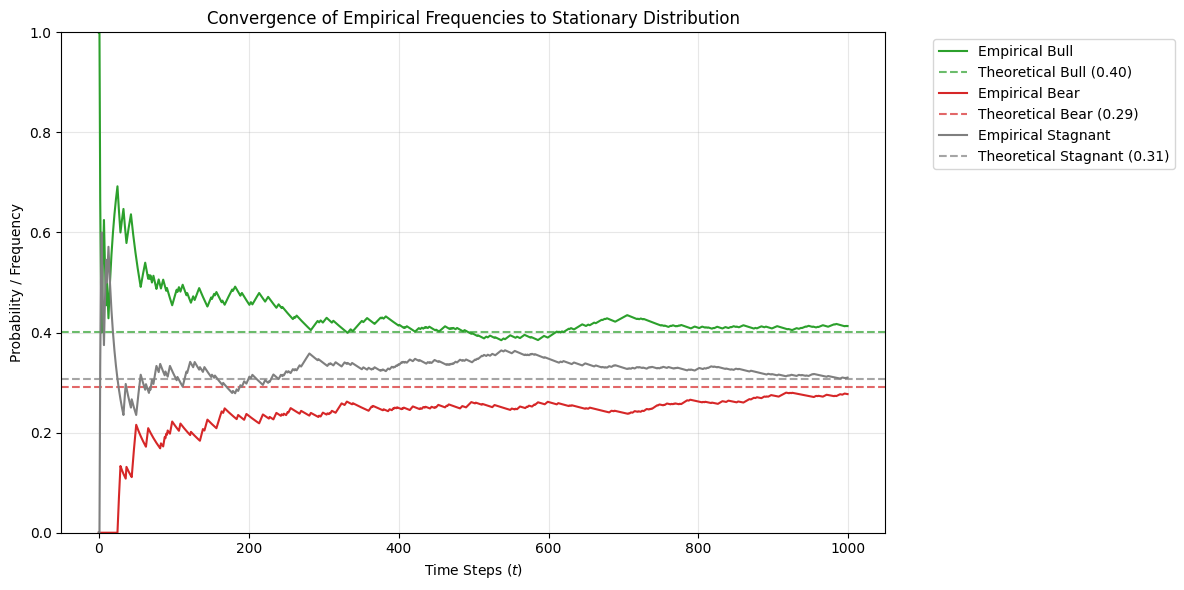

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. State Space and Transition Matrix Definition
states = ['Bull', 'Bear', 'Stagnant']
num_states = len(states)

P = np.array([
    [0.70, 0.10, 0.20],  # From Bull: 70% stay Bull, 10% to Bear, 20% to Stagnant
    [0.15, 0.60, 0.25],  # From Bear: 15% to Bull, 60% stay Bear, 25% to Stagnant
    [0.25, 0.25, 0.50]   # From Stagnant: 25% to Bull, 25% to Bear, 50% stay Stagnant
])

# Verify row stochasticity
assert np.allclose(P.sum(axis=1), 1.0), "Transition matrix rows must sum to 1"

# 2. Analytical Stationary Distribution
eigenvalues, eigenvectors = np.linalg.eig(P.T)

# Find the index of the eigenvalue closest to 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary_vector = np.real(eigenvectors[:, idx])

# Normalize to ensure it's a valid probability distribution
pi = stationary_vector / np.sum(stationary_vector)

print("Theoretical Stationary Distribution (\u03C0):")
for i, state in enumerate(states):
    print(f"  {state}: {pi[i]:.4f}")

# 3. Monte Carlo Simulation of the Markov Chain
np.random.seed(42)
num_steps = 1000
path = np.zeros(num_steps, dtype=int)

# Initialize at state 0 (Bull Market)
path[0] = 0

# Simulate the path
for t in range(1, num_steps):
    current_state = path[t-1]
    # np.random.choice uses the probabilities from the current state's row in P
    next_state = np.random.choice(num_states, p=P[current_state])
    path[t] = next_state

# 4. Empirical Convergence Validation
empirical_frequencies = np.zeros((num_steps, num_states))
for state in range(num_states):
    empirical_frequencies[:, state] = np.cumsum(path == state) / np.arange(1, num_steps + 1)

# Visualization
plt.figure(figsize=(12, 6))

colors = ['#2ca02c', '#d62728', '#7f7f7f'] # Green, Red, Grey

for state in range(num_states):
    plt.plot(empirical_frequencies[:, state], label=f'Empirical {states[state]}', color=colors[state])
    # Plot theoretical horizontal lines
    plt.axhline(pi[state], color=colors[state], linestyle='--', alpha=0.7, 
                label=f'Theoretical {states[state]} ({pi[state]:.2f})')

plt.title("Convergence of Empirical Frequencies to Stationary Distribution")
plt.xlabel("Time Steps ($t$)")
plt.ylabel("Probability / Frequency")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
